In [1]:
from typing import cast
import pandas as pd
import numpy as np
import bs4
import requests
from typing import Coroutine
import asyncio
import httpx
from typing import Any
SEMAFORO=asyncio.Semaphore(20)
import re
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
url_principal:str='https://www.pisos.com'
pd.set_option('display.max_columns',None)
K=1.5
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
from sklearn.preprocessing import TargetEncoder,StandardScaler
from sklearn.impute import KNNImputer

In [ ]:
soup:bs4.BeautifulSoup=bs4.BeautifulSoup(requests.get(url=url_principal+'/viviendas/madrid').text,'html.parser')
links:bs4.ResultSet=cast(bs4.Tag,soup.find(class_='zoneList')).find_all(class_='seo-box__location-link--level2')
zonas_madrid:list[str]=[link['href'] for link in links]
zonas_madrid

['/viviendas/corredor_del_henares/',
 '/viviendas/madrid_capital/',
 '/viviendas/madrid_noroeste/',
 '/viviendas/madrid_norte/',
 '/viviendas/madrid_sur/',
 '/viviendas/madrid_sureste/',
 '/viviendas/madrid_suroeste/']

In [3]:
async def consultar_html_region(url:str,client:httpx.AsyncClient)->str:
    result:httpx.Response=await client.get(url_principal+url)
    return result.text
async def consultar_htmls_zonas(zonas:list[str])->list[str]:
    async with httpx.AsyncClient() as client:
        tareas:list[Coroutine[Any,Any,str]]=[consultar_html_region(zona,client) for zona in zonas]
        tareas_completas:list[str]=await asyncio.gather(*tareas)
        return tareas_completas
htmls_zonas:list[str]=await consultar_htmls_zonas(zonas_madrid)
transform_zonas:list[bs4.Tag]=[cast(bs4.Tag,bs4.BeautifulSoup(html,'html.parser').body) for html in htmls_zonas]

In [4]:
def sacar_n_boton(zona:bs4.Tag)->tuple[str,int]:
    boton:bs4.Tag=cast(bs4.Tag,zona.find(class_='button__primary'))
    return str(boton['href']),int(boton.text.split(' ')[1].replace('.',''))
async def consultar_urls_zonas(zona:bs4.Tag)->list[str]:
    lista:list[str]=[]
    en,n_resultados=sacar_n_boton(zona)
    if n_resultados>3000:
        zoneList:bs4.Tag=cast(bs4.Tag,zona.find(class_='zoneList'))
        enlaces:list[bs4.Tag]=zoneList.find_all(class_='seo-box__location-link--level2')
        hrefs:list[str]=[str(a['href']) for a in enlaces]
        hrefs_viviendas:list[str]=list(filter(lambda x:'/viviendas/' in x,hrefs))
        hrefs_ventas:list[str]=list(filter(lambda x:x not in hrefs_viviendas,hrefs))
        htmls:list[str]=await consultar_htmls_zonas(hrefs_viviendas)
        transforms:list[bs4.Tag]=[cast(bs4.Tag,bs4.BeautifulSoup(html,'html.parser').body) for html in htmls]
        lista.extend(href for href,n in [sacar_n_boton(z) for z in transforms])
        lista.extend(hrefs_ventas)
    else:
        lista=[en]
    return lista
lista_urls_zonas:list[str]=[url for zona in [(await consultar_urls_zonas(zona)) for zona in transform_zonas] for url in zona]
lista_urls_zonas

['/venta/pisos-corredor_del_henares/',
 '/venta/pisos-arganzuela/',
 '/venta/pisos-madrid_capital_salamanca/',
 '/venta/pisos-madrid_capital_carabanchel/',
 '/venta/pisos-madrid_capital_centro/',
 '/venta/pisos-madrid_capital_chamartin/',
 '/venta/pisos-chamberi_distrito/',
 '/venta/pisos-ciudad_lineal/',
 '/venta/pisos-fuencarral_el_pardo/',
 '/venta/pisos-hortaleza/',
 '/venta/pisos-latina/',
 '/venta/pisos-moncloa_aravaca/',
 '/venta/pisos-puente_de_vallecas/',
 '/venta/pisos-madrid_capital_retiro/',
 '/venta/pisos-madrid_capital_san_blas/',
 '/venta/pisos-tetuan/',
 '/venta/pisos-madrid_capital_usera/',
 '/venta/pisos-madrid_capital_vicalvaro/',
 '/venta/pisos-villa_de_vallecas/',
 '/venta/pisos-villaverde_distrito/',
 '/venta/pisos-madrid_capital_barajas/',
 '/venta/pisos-moratalaz/',
 '/venta/pisos-madrid_noroeste/',
 '/venta/pisos-madrid_norte/',
 '/venta/pisos-madrid_sur/',
 '/venta/pisos-madrid_sureste/',
 '/venta/pisos-madrid_suroeste/']

In [5]:
async def consultar_n_paginas_opcion_localidad(id:int,u:str,client:httpx.AsyncClient)-> dict[int,int]:
    result:httpx.Response=await client.get(url_principal+u)
    posible:bs4.Tag | None=bs4.BeautifulSoup(result.text,'html.parser').find(class_='grid__title')
    n:str='0'
    if title:=posible:
        r:str=title.find_all('span')[1].text
        if len(r)>0:
            n=r.split(' ')[0]
    resultados:int=int(n.replace('.',''))
    n_paginas_completas:int=resultados//30
    n_paginas:int=int(np.min([n_paginas_completas+(resultados>(30*n_paginas_completas)),100]))
    return {id:n_paginas}
async def sacar_n_paginas()->dict[int,int]:
    async with httpx.AsyncClient(transport=httpx.AsyncHTTPTransport(retries=1)) as client:
        tareas:list[Coroutine[Any,Any,dict[int,int]]]=[consultar_n_paginas_opcion_localidad(id,u,client) for id,u in enumerate(lista_urls_zonas)]
        tareas_completas:list[dict[int,int]]=await asyncio.gather(*tareas)
        return {k:v for d in tareas_completas for k,v in d.items()}
n_paginas:dict[int,int]=await sacar_n_paginas()
n_paginas

{0: 31,
 1: 10,
 2: 46,
 3: 13,
 4: 33,
 5: 12,
 6: 20,
 7: 15,
 8: 8,
 9: 8,
 10: 10,
 11: 11,
 12: 13,
 13: 13,
 14: 10,
 15: 11,
 16: 8,
 17: 5,
 18: 6,
 19: 9,
 20: 3,
 21: 3,
 22: 59,
 23: 32,
 24: 51,
 25: 13,
 26: 25}

In [6]:
async def consultar_anuncios_cargados(client:httpx.AsyncClient,url:str,pagina:int)->str:# junta todos los anuncios de una página de una localidad
    async with SEMAFORO:
        result:httpx.Response=await client.get(f"{url_principal}{url}{pagina}",timeout=10)
        return result.text
async def consultar_anuncios_url(client:httpx.AsyncClient,url:str)->list[str]: # junta todos los anuncios de una localidad
    tareas:list[Coroutine[Any,Any,str]]=[consultar_anuncios_cargados(client,url,i) for i in range(1,n_paginas[lista_urls_zonas.index(url)]+1)]
    tareas_completas:list[str]=await asyncio.gather(*tareas)
    return tareas_completas
async def consultar_anuncios(lista_urls:list[str])->list[str]: # junta todos los anuncios
    async with httpx.AsyncClient(transport=httpx.AsyncHTTPTransport(retries=1),limits=httpx.Limits(max_connections=20,max_keepalive_connections=20)) as client:
        tareas:list[Coroutine[Any,Any,list[str]]]=[consultar_anuncios_url(client,url) for url in lista_urls]
        tareas_completas:list[list[str]]=await asyncio.gather(*tareas)
        anuncios:list[str]=[u for lista in tareas_completas for u in lista]
    transformados:list[bs4.ResultSet]=[bs4.BeautifulSoup(ad,'html.parser').find_all(class_='ad-preview') for ad in anuncios]
    lista_ads=[ad for rs in transformados for ad in rs]
    return [f"{url_principal}{ad['data-lnk-href']}" for ad in lista_ads]

In [ ]:
ventas_ads:list[str]=list(set(await consultar_anuncios(lista_urls_zonas)))
ventas_ads

['https://www.pisos.com/comprar/piso-zona_sureste-63411718761_100500/',
 'https://www.pisos.com/comprar/piso-pryconsa_juan_de_austria28804-64242618195_994867/',
 'https://www.pisos.com/comprar/piso-pryconsa_juan_de_austria28804-65043163226_271200/',
 'https://www.pisos.com/comprar/piso-rinconada28802-64198451305_271200/',
 'https://www.pisos.com/comprar/casa_adosada-loeches_centro_urbano-65896755914_106100/',
 'https://www.pisos.com/comprar/piso-rinconada28803-65028271140_271200/',
 'https://www.pisos.com/comprar/piso-zona_noroeste-65929071312_101000/',
 'https://www.pisos.com/comprar/chalet_adosado-zona_suroeste-54185554852_517810/',
 'https://www.pisos.com/comprar/duplex-avicola_san_nicolas-63407639828_100500/',
 'https://www.pisos.com/comprar/piso-zona_sureste-63396336971_100500/',
 'https://www.pisos.com/comprar/piso-pryconsa_juan_de_austria28804-64205427845_100200/',
 'https://www.pisos.com/comprar/piso-coslada_casco_antiguo-64241709886_100200/',
 'https://www.pisos.com/comprar/ca

In [17]:
ventas_ads=list(set(ventas_ads))

In [18]:
with open('./anuncios.txt','w') as f:
    f.writelines([f"{ad}\n" for ad in ventas_ads])

In [1]:
with open('./anuncios.txt','r') as f:
    ads_copia=[ad[:-2] for ad in f.readlines()]
ads_copia

['https://www.pisos.com/comprar/atico-cortes_huertas28014-63393178826_109200',
 'https://www.pisos.com/comprar/piso-justicia_chueca28004-62508498356_109200',
 'https://www.pisos.com/comprar/piso-madrid_capital_carabanchel-64252985931_106700',
 'https://www.pisos.com/comprar/piso-fuente_del_berro28017-63384011882_102100',
 'https://www.pisos.com/comprar/piso-ciudad_lineal_colina-63391210948_109200',
 'https://www.pisos.com/comprar/piso-latina_aluche28024-63375110020_518874',
 'https://www.pisos.com/comprar/piso-alcobendas_centro28100-65045189989_109800',
 'https://www.pisos.com/comprar/piso-orcasur28041-62568618264_991741',
 'https://www.pisos.com/comprar/piso-san_sebastian_de_los_reyes_casco_antiguo28701-64253228398_100200',
 'https://www.pisos.com/comprar/piso-prado_de_somosaguas-65865887620_100500',
 'https://www.pisos.com/comprar/piso-goya28001-65933168094_106100',
 'https://www.pisos.com/comprar/piso-acacias-65893764205_106100',
 'https://www.pisos.com/comprar/piso-acacias28005-550

In [4]:
clases:list[str]=list(map(lambda x:str(x),np.unique(list(map(lambda x:x[x[:x.find('-')].rfind('/')+1:x.find('-')],ads_copia)))))
clases

['apartamento',
 'atico',
 'casa',
 'casa_adosada',
 'casa_pareada',
 'casa_rustica',
 'casa_unifamiliar',
 'chalet',
 'chalet_adosado',
 'chalet_pareado',
 'chalet_rustico',
 'chalet_unifamiliar',
 'duplex',
 'estudio',
 'finca_rustica',
 'loft',
 'piso']

In [7]:
async def consultar_html_ad(url:str,client:httpx.AsyncClient)->str:
    async with SEMAFORO:
        response:httpx.Response=await client.get(url,timeout=10)
        # features:bs4.ResultSet=bs4.BeautifulSoup(response.text,'html.parser').find_all(class_='features__label')
        # return [feature.text for feature in features]
        return response.text
async def consultar_htmls_ads(urls:list[str],comunes:bool=False)->list[str]:
    async with httpx.AsyncClient(transport=httpx.AsyncHTTPTransport(retries=1),limits=httpx.Limits(max_connections=20,max_keepalive_connections=20)) as client:
        tareas:list[Coroutine[Any,Any,str]]=[consultar_html_ad(vivienda,client) for vivienda in urls]
        tareas_completas:list[str]=await asyncio.gather(*tareas)
        return tareas_completas

In [28]:
htmls_ads:list[str]=await consultar_htmls_ads(ventas_ads)

In [35]:
for i,add in enumerate(ventas_ads):
    with open(f'./htmls/{add.split('/')[-2]}.html','w',encoding='utf-8') as f:
        f.write(htmls_ads[i])

In [8]:
htmls_copia:list[str]=[]
for i,add in enumerate(ads_copia):
    with open(f'./htmls/{add.split('/')[-1]}.html','r',encoding='utf-8') as f:
        htmls_copia.append(f.read())

In [9]:
async def sacar_detalles(html:str)->bs4.Tag:
    parseado=bs4.BeautifulSoup(html,'lxml')
    return cast(bs4.Tag,parseado.find(class_='details__col-right'))
async def sacar_detalles_htmls(htmls:list[str])->list[bs4.Tag]:
    tareas:list[Coroutine[Any,Any,bs4.Tag]]=[sacar_detalles(html) for html in htmls]
    return await asyncio.gather(*tareas)
details_parsed:list[bs4.Tag]=await sacar_detalles_htmls(htmls_copia)

In [ ]:
for i,t in enumerate(details_parsed):
    with open(f'./details_htmls/details-{ads_copia[i].split('/')[-1]}.html','w',encoding='utf-8') as f:
        f.write(str(t))

In [25]:
details_htmls:list[str]=[]
for i,a in enumerate(ads_copia):
    with open(f'./details_htmls/details-{a.split('/')[-1]}.html','r',encoding='utf-8') as f:
        details_htmls.append(f.read())

In [30]:
for i,t in enumerate(details_htmls):
    with open(f'./details_pkls/details-{ads_copia[i].split('/')[-1]}.pkl','wb') as f:
        pickle.dump(bs4.BeautifulSoup(str(t),'html.parser'),f)

In [9]:
ruta:str='./details_pkls/'
archivos=os.listdir(ruta)
details_list:list[bs4.Tag]=[]
async def cargar_archivo(archivo:str)->bs4.Tag:
    with open(f'{ruta}{archivo}','rb') as f:
        return pickle.load(f)
async def cargar_archivos(lista:list[str])->list[bs4.Tag]:
    tareas:list[Coroutine[Any,Any,bs4.Tag]]=[cargar_archivo(archivo) for archivo in lista]
    tareas_completas:list[bs4.Tag]=await asyncio.gather(*tareas)
    return tareas_completas
details_list=await cargar_archivos(archivos)

In [10]:
lista_listas_caracteristicas:list[bs4.ResultSet]=[cast(bs4.Tag,v.find(class_='features-container')).find_all(class_='features__label') for v in details_list]

In [11]:
lista_caracteristicas=list({f"{c.text}" for lista in lista_listas_caracteristicas for c in lista})
lista_caracteristicas

['Vidrios dobles: ',
 'Orientación: ',
 'Urbanizado: ',
 'Se aceptan mascotas',
 'Carpintería exterior',
 'Planta: ',
 'Gastos de comunidad',
 'Antigüedad: ',
 'Aire acondicionado',
 'Superficie útil: ',
 'Armarios empotrados: ',
 'Conservación: ',
 'Agua: ',
 'Armarios empotrados',
 'Gas: ',
 'Portero automático: ',
 'Superficie solar: ',
 'Piscina',
 'Exterior',
 'Garaje: ',
 'No se aceptan mascotas',
 'Comedor: ',
 'Piscina: ',
 'Lavadero: ',
 'Lavadero',
 'Soleado',
 'Comedor',
 'Amueblado: ',
 'Referencia: ',
 'Tipo suelo: ',
 'Ascensor',
 'Interior: ',
 'Orientación',
 'Teléfono',
 'Calefacción',
 'Luz: ',
 'Exterior: ',
 'Urbanizado',
 'Sistema de seguridad',
 'Habitaciones: ',
 'Vidrios dobles',
 'Terraza',
 'Ascensor: ',
 'Puerta blindada',
 'Superficie construida: ',
 'Sistema de seguridad: ',
 'Baños: ',
 'Gas',
 'Soleado: ',
 'Gastos de comunidad: ',
 'Garaje',
 'Trastero',
 'Chimenea',
 'Balcón',
 'Luz',
 'Puerta blindada: ',
 'Teléfono: ',
 'Aire acondicionado: ',
 'Carpi

In [12]:
caracteristicas_especificables=list(map(lambda x:x[:-2],filter(lambda x:': ' in x and x[:-2] in lista_caracteristicas,lista_caracteristicas)))
caracteristicas_especificables

['Vidrios dobles',
 'Orientación',
 'Urbanizado',
 'Armarios empotrados',
 'Agua',
 'Gas',
 'Portero automático',
 'Garaje',
 'Comedor',
 'Piscina',
 'Lavadero',
 'Amueblado',
 'Tipo suelo',
 'Interior',
 'Luz',
 'Exterior',
 'Ascensor',
 'Sistema de seguridad',
 'Soleado',
 'Gastos de comunidad',
 'Puerta blindada',
 'Teléfono',
 'Aire acondicionado',
 'Terraza',
 'Trastero',
 'Cocina equipada',
 'Carpintería exterior',
 'Calefacción',
 'Carpintería interior',
 'Chimenea',
 'Jardín']

In [13]:
caracteristicas_especificables_json=list(map(lambda x:x.replace(' ','_').lower().replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u'),caracteristicas_especificables))
caracteristicas_especificables_json

['vidrios_dobles',
 'orientacion',
 'urbanizado',
 'armarios_empotrados',
 'agua',
 'gas',
 'portero_automatico',
 'garaje',
 'comedor',
 'piscina',
 'lavadero',
 'amueblado',
 'tipo_suelo',
 'interior',
 'luz',
 'exterior',
 'ascensor',
 'sistema_de_seguridad',
 'soleado',
 'gastos_de_comunidad',
 'puerta_blindada',
 'telefono',
 'aire_acondicionado',
 'terraza',
 'trastero',
 'cocina_equipada',
 'carpinteria_exterior',
 'calefaccion',
 'carpinteria_interior',
 'chimenea',
 'jardin']

In [14]:
caracteristicas_no_especificables=list(filter(lambda x:x not in caracteristicas_especificables and x.replace(': ','') not in caracteristicas_especificables,lista_caracteristicas))
caracteristicas_no_especificables

['Se aceptan mascotas',
 'Planta: ',
 'Antigüedad: ',
 'Superficie útil: ',
 'Conservación: ',
 'Superficie solar: ',
 'No se aceptan mascotas',
 'Referencia: ',
 'Habitaciones: ',
 'Superficie construida: ',
 'Baños: ',
 'Balcón',
 'Calle alumbrada',
 'Tipo de casa: ',
 'Calle asfaltada',
 'Adaptado a personas con movilidad reducida']

In [15]:
booleanos=list(filter(lambda x:': ' not in x,caracteristicas_no_especificables))
booleanos

['Se aceptan mascotas',
 'No se aceptan mascotas',
 'Balcón',
 'Calle alumbrada',
 'Calle asfaltada',
 'Adaptado a personas con movilidad reducida']

In [16]:
booleanos_json=list(map(lambda x:x.replace(' ','_').lower().replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u'),booleanos))
booleanos_json

['se_aceptan_mascotas',
 'no_se_aceptan_mascotas',
 'balcon',
 'calle_alumbrada',
 'calle_asfaltada',
 'adaptado_a_personas_con_movilidad_reducida']

In [22]:
no_booleanos=list(map(lambda x:x[:-2],filter(lambda x:x not in booleanos,caracteristicas_no_especificables)))
no_booleanos.remove('Tipo de casa')
no_booleanos

['Planta',
 'Antigüedad',
 'Superficie útil',
 'Conservación',
 'Superficie solar',
 'Referencia',
 'Habitaciones',
 'Superficie construida',
 'Baños']

In [23]:
no_booleanos_json=list(map(lambda x:x.replace(' ','_').lower().replace('ñ','nh').replace('ü','u').replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u'),no_booleanos))
no_booleanos_json

['planta',
 'antiguedad',
 'superficie_util',
 'conservacion',
 'superficie_solar',
 'referencia',
 'habitaciones',
 'superficie_construida',
 'banhos']

In [19]:
sin_precio_superficie=list(filter(lambda v:not v.find('li',class_='features-summary__item',string=re.compile('€/m²')),details_list))

In [71]:
async def jsonear(v:bs4.Tag)->dict[str,Any]:
    json:dict[str,Any]={}
    json['nombre']=str(cast(bs4.Tag,v.find(class_='js-share'))['data-url']).replace(f'{url_principal}/comprar/','').replace('/','')
    posible_precio=str(cast(bs4.Tag,v.find(class_='jsPriceValue')).text).split(' ')[0].replace('.','').replace(',','.')
    json['precio']=None if not len(re.findall("\\d",posible_precio))==len(posible_precio.replace('.','')) else float(posible_precio)
    json['tipo']=json['nombre'].split('-')[0]
    precio_superficie:float | None=None
    consumo:float | None=None
    emisiones:float | None=None
    descripcion:str | None=None
    div_caracteristicas:bs4.Tag=cast(bs4.Tag,v.find(class_='features-container'))
    for nb,nbj in zip(no_booleanos,no_booleanos_json):
        value=None
        posible=div_caracteristicas.find('span',class_='features__label',string=f"{nb}: ")
        if confirmado:=posible:
            value=cast(bs4.Tag,confirmado.find_next_sibling('span')).text
            if 'superficie' in nbj:
                value=float(value.split(' ')[0].replace('.','').replace(',','.'))
            if nbj in ['habitaciones','banhos']:
                value=int(value)
        json[nbj]=value
    for b,bj in zip(booleanos,booleanos_json):
        posible=div_caracteristicas.find(class_='features__label',string=b)
        if posible:
            if bj=='no_se_aceptan_mascotas':
                json['se_aceptan_mascotas']=False
            else:
                json[bj]=True
        else:
            if bj!='no_se_aceptan_mascotas':
                if bj!='se_aceptan_mascotas' or not 'se_aceptan_mascotas' in json.keys():
                    json[bj]=None
    for e,ej in zip(caracteristicas_especificables,caracteristicas_especificables_json):
        value=None
        for sufijo in ['',': ']:
            posible=div_caracteristicas.find('span',class_='features__label',string=f"{e}{sufijo}")
            if confirmado:=posible:
                value=True
                if confirmado:=confirmado.find_next_sibling('span'):
                    value=confirmado.text
        json[ej]=value
    
    posible_ps=v.find('li',class_='features-summary__item',string=re.compile('€/m²'))
    posible_consumo=v.find('span',string=re.compile('kWh/m²'))
    posible_emisiones=v.find('span',string=re.compile('CO₂/m²'))
    posible_desc=v.find(class_='description__content')
    
    if confirmado:=posible_ps:
        precio_superficie=float(confirmado.text.split(' ')[0].replace('.','').replace(',','.'))
    if confirmado:=posible_consumo:
        consumo=float(confirmado.text.split(' ')[0].replace('.','').replace(',','.'))
    if confirmado:=posible_emisiones:
        emisiones=float(confirmado.text.split(' ')[0].replace('.','').replace(',','.'))
    if confirmado:=posible_desc:
        descripcion=confirmado.text
    
    return {
        **json,
        'precio_superficie':precio_superficie,
        'consumo':consumo,
        'emisiones':emisiones,
        'descripcion':descripcion,
    }
async def sacar_jsons(lista:list[bs4.Tag])->list[dict[str,Any]]:
    tareas:list[Coroutine[Any,Any,dict[str,Any]]]=[jsonear(x) for x in lista]
    tareas_completas:list[dict[str,Any]]=await asyncio.gather(*tareas)
    return tareas_completas

In [76]:
jsons=await sacar_jsons(details_list)

In [ ]:
df:pd.DataFrame=pd.DataFrame(jsons)
df=df.assign(
    descripcion=list(map(lambda x:bs4.BeautifulSoup(x,'html.parser').text.replace('\xa0',' '),df['descripcion']))
)

NameError: name 'jsons' is not defined

In [2]:
df.to_csv('datos_crudos.csv',index=False)

NameError: name 'df' is not defined

In [209]:
df=pd.read_csv('./datos_crudos.csv')
df=df.assign(
    localidad=df['nombre'].map(lambda x:str(x).split('-')[1]),
    localidad_sin_numero=df['localidad'].map(lambda x:re.sub("\\d",'',str(x))),
    cp=df['localidad'].map(lambda x:re.sub("[^0-9]",'',str(x))).map(lambda x:x if len(str(x))==5 else np.nan),
    antiguedad_media=np.select(
        [df['antiguedad']=='Más de 50 años',df['antiguedad']=='Entre 30 y 50 años',df['antiguedad']=='Entre 20 y 30 años',df['antiguedad']=='Entre 10 y 20 años',df['antiguedad']=='Entre 5 y 10 años',df['antiguedad']=='Menos de 5 años'],
        [51,50,30,20,10,5],
        np.nan
    ),
    n_conservacion=np.select(
        [df['conservacion']=='A reformar',df['conservacion']=='En buen estado',df['conservacion']=='Reformado',df['conservacion']=='A estrenar'],
        [1,2,3,4],
        np.nan
    ),
    balcon=np.where(
        (df['balcon'].isna()) & ~((df['descripcion'].str.contains('balcón')) | (df['descripcion'].str.contains('Balcón')) | (df['descripcion'].str.contains('balcones'))),False,df['balcon']
    ),
    n_planta=np.where(
        (~df.fillna('nan')['planta'].isna()),df['planta'].map(lambda x:-1 if x=='Sótano' else -0.5 if x=='Semisótano' else 0 if x=='Bajo' else 0.5 if x=='Entresuelo' else 1 if x=='Principal' else 21 if x=='Más de 20' else float(str(x).replace('ª',''))),np.nan
    ),
    piscina=np.where(
        (df['piscina'].isna() & ~((df['descripcion'].str.contains('piscina')) | (df['descripcion'].str.contains('Piscina')))),False,df['piscina']
    )
)
df=df.assign(
    n_planta=np.where(
        df['tipo'].isin(['casa','casa_adosada','chalet','finca_rustica']),0,df['n_planta']
    )
)
df_reducido:pd.DataFrame=df[((df['superficie_construida'].between(16,348.5)) | (df['superficie_construida'].isna())) & ((df['superficie_util'].between(16,294.5)) | (df['superficie_util'].isna())) & ((df['banhos'].between(0,6)) | (df['banhos'].isna())) & (df['precio'].between(500,3000000)) & ((df['habitaciones'].between(1,7)) | (df['habitaciones'].isna())) & ((df['superficie_solar'].between(15,4679.875)) | (df['superficie_solar'].isna())) & ((df['precio_superficie'].between(10,13555.5)) | (df['precio_superficie'].isna())) & ((df['consumo'].between(0,471)) | (df['consumo'].isna())) & ((df['emisiones'].between(0,112)) | (df['emisiones'].isna())) & ~((df['conservacion']=='En buen estado') & (df['precio']<30000)) & ~((df['conservacion']=='A reformar') & (df['precio']>1000000))]
df_reducido

,nombre,precio,tipo,planta,antiguedad,superficie_util,habitaciones,superficie_construida,superficie_solar,conservacion,referencia,banhos,calle_alumbrada,calle_asfaltada,balcon,se_aceptan_mascotas,adaptado_a_personas_con_movilidad_reducida,jardin,lavadero,carpinteria_exterior,cocina_equipada,tipo_suelo,orientacion,exterior,chimenea,gastos_de_comunidad,ascensor,armarios_empotrados,sistema_de_seguridad,terraza,urbanizado,garaje,trastero,amueblado,soleado,comedor,telefono,vidrios_dobles,luz,aire_acondicionado,gas,interior,portero_automatico,carpinteria_interior,agua,calefaccion,puerta_blindada,piscina,precio_superficie,consumo,emisiones,descripcion,localidad,antiguedad_media,localidad_sin_numero,cp,n_conservacion,n_planta
0,apartamento-abrantes-65041026653_100500,295000.0,apartamento,3ª,Más de 50 años,74.0,3.0,80.0,NaN,En buen estado,ABR/9927,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,True,Parquet,Este,NaN,NaN,Entre 20 y 40 €,NaN,1,NaN,NaN,NaN,NaN,True,NaN,True,NaN,True,NaN,Otra compañía,True,NaN,True,NaN,True,True,Gas natural,True,False,3687.0,NaN,NaN,\n\t\t\t\t**Piso exterior muy luminoso junto a...,abrantes,51.0,abrantes,NaN,2.0,3.0
1,apartamento-acacias28005-63376212013_109800,560000.0,apartamento,Bajo,Más de 50 años,57.0,2.0,60.0,NaN,En buen estado,23340459,1.0,NaN,NaN,False,NaN,True,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,Entre 80 y 100 €,NaN,NaN,NaN,True,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,9333.0,NaN,NaN,\n\t\t\t\tMuy buena ubicación a cinco minutos ...,acacias28005,51.0,acacias,28005,2.0,0.0
2,apartamento-acacias28005-63421570468_105600,495000.0,apartamento,NaN,NaN,NaN,3.0,75.0,NaN,NaN,VM2511091,2.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,6600.0,NaN,NaN,\n\t\t\t\tEstupendo dúplex en Arganzuela refor...,acacias28005,NaN,acacias,28005,NaN,NaN
3,apartamento-adelfas28007-63427703595_105600,699000.0,apartamento,NaN,NaN,NaN,3.0,116.0,NaN,NaN,VM2510063,3.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,6025.0,NaN,NaN,\n\t\t\t\tAProperties presenta este precioso p...,adelfas28007,NaN,adelfas,28007,NaN,NaN
4,apartamento-adelfas28007-65928881028_105600,530000.0,apartamento,NaN,NaN,NaN,1.0,91.0,NaN,NaN,VM2607043,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,5824.0,NaN,NaN,\n\t\t\t\tPresentamos una excelente oportunida...,adelfas28007,NaN,adelfas,28007,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14033,piso-zona_suroeste-65846608920_106100,344500.0,piso,3ª,Entre 20 y 30 años,90.0,2.0,90.0,NaN,En buen estado,111905353-BS0032,2.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,Central,NaN,True,3827.0,NaN,NaN,\n\t\t\t\tPiso Exterior Luminoso en Torrejón d...,zona_suroeste,30.0,zona_suroeste,NaN,2.0,3.0
14034,piso-zona_suroeste-65861155816_106600,265000.0,piso,NaN,NaN,84.0,2.0,84.0,NaN,Reformado,1167,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,Central,NaN,False,3154.0,NaN,NaN,\n\t\t\t\tPrecioso piso en venta en Torrejón D...,zona_suroeste,NaN,zona_suroeste,NaN,3.0,NaN
14035,piso-zona_suroeste-65871635784_100500,265000.0,piso,4ª,Entre 20 y 30 años,NaN,2.0,73.0,NaN,En buen estado,AM260234,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,Cocina amueblada,NaN,Suroeste,True,NaN,Entre 60 y 80 €,True,1,NaN,NaN,NaN,1,True,NaN,NaN,NaN,NaN,NaN,NaN,Frío,NaN,NaN,NaN,NaN,NaN,Gas natural,NaN,False,3630.0,NaN,NaN,\n\t\t\t\tAgora gestores inmobiliarios ven

In [177]:
df_reducido[df_reducido['garaje']=='1'].sort_values(by=['precio']).iloc[0]['nombre']

'piso-garena28806-63377685027_109800'

In [176]:
df_reducido.fillna('NaN').groupby('garaje').describe()['precio'].reset_index().sort_values(by=['50%'])

,garaje,count,mean,std,min,25%,50%,75%,max
5,Opcional,1.0,3.100000e+05,NaN,310000.0,310000.0,310000.0,310000.0,310000.0
4,NaN,8643.0,5.303773e+05,490680.021304,1200.0,229000.0,320000.0,650000.0,2990000.0
2,Comunitario 1 plazas,1.0,4.750000e+05,NaN,475000.0,475000.0,475000.0,475000.0,475000.0
7,True,348.0,5.708363e+05,376046.975779,84000.0,373250.0,485900.0,625550.0,2700000.0
0,1,2430.0,6.977695e+05,531968.518775,1400.0,339925.0,499000.0,853375.0,3000000.0
3,Más de 2,48.0,6.727704e+05,436318.439569,199999.0,475500.0,599900.0,766250.0,2700000.0
1,2,216.0,9.212603e+05,533790.962322,158000.0,567500.0,755000.0,1150000.0,2700000.0
6,Privado,1.0,2.590000e+06,NaN,2590000.0,2590000.0,2590000.0,2590000.0,2590000.0


In [212]:
columna=df[df['conservacion']=='A reformar'].dropna(subset=['conservacion'])['precio']
q1=np.quantile(a=columna,q=0.25)
q3=np.quantile(a=columna,q=0.75)
iqr=q3-q1
print(q1,iqr,q3)
lim_inf=q1-K*iqr
lim_sup=q3+K*iqr
print(lim_inf,lim_sup)

225000.0 514500.0 739500.0
-546750.0 1511250.0


In [34]:
df_reducido.columns

Index(['nombre', 'precio', 'tipo', 'planta', 'antiguedad', 'superficie_util',
       'habitaciones', 'superficie_construida', 'superficie_solar',
       'conservacion', 'referencia', 'banhos', 'calle_alumbrada',
       'calle_asfaltada', 'balcon', 'se_aceptan_mascotas',
       'adaptado_a_personas_con_movilidad_reducida', 'jardin', 'lavadero',
       'carpinteria_exterior', 'cocina_equipada', 'tipo_suelo', 'orientacion',
       'exterior', 'chimenea', 'gastos_de_comunidad', 'ascensor',
       'armarios_empotrados', 'sistema_de_seguridad', 'terraza', 'urbanizado',
       'garaje', 'trastero', 'amueblado', 'soleado', 'comedor', 'telefono',
       'vidrios_dobles', 'luz', 'aire_acondicionado', 'gas', 'interior',
       'portero_automatico', 'carpinteria_interior', 'agua', 'calefaccion',
       'puerta_blindada', 'piscina', 'precio_superficie', 'consumo',
       'emisiones', 'descripcion', 'localidad', 'antiguedad_media',
       'localidad_sin_numero', 'n_conservacion', 'n_planta'],
      

In [208]:
columna=df_reducido[df_reducido['conservacion']=='En buen estado'].dropna(subset=['conservacion'])['precio']
q1=np.quantile(a=columna,q=0.25)
q3=np.quantile(a=columna,q=0.75)
iqr=q3-q1
print(q1,iqr,q3)
lim_inf=q1-K*iqr
lim_sup=q3+K*iqr
print(lim_inf,lim_sup)

233000.0 267000.0 500000.0
-167500.0 900500.0


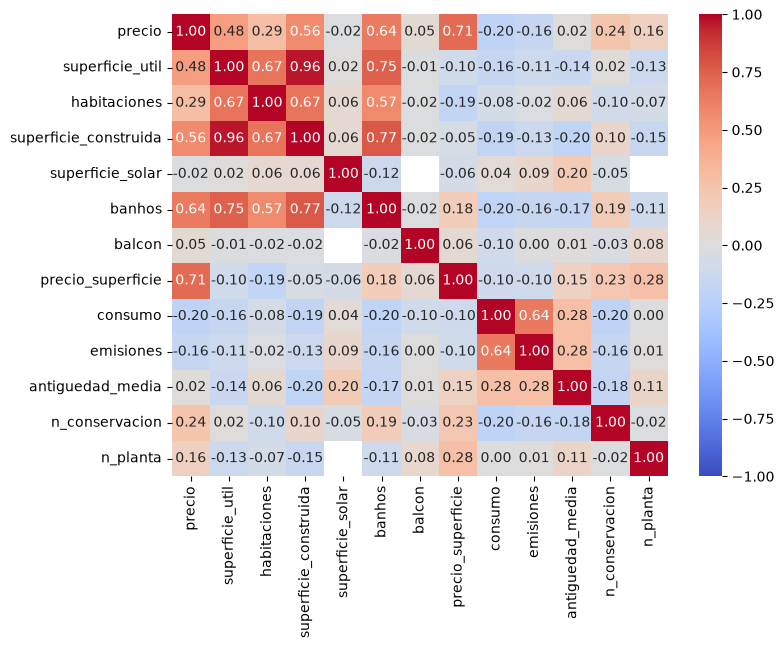

In [210]:
# [(df_reducido['superficie_construida']>df_reducido['superficie_util']) | (df_reducido['superficie_construida'].isna()) | (df_reducido['superficie_util'].isna())]
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_reducido.dropna(subset=['balcon']).assign(balcon=df_reducido['balcon']==True).corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0
)
plt.show()

In [206]:
df_reducido[df_reducido['conservacion']=='A reformar'].sort_values(by=['precio'],ascending=False).iloc[1]['nombre']

'piso-justicia_chueca28004-53402534155_100500'

In [211]:
df_reducido.fillna('NaN').groupby('conservacion').describe()['precio'].reset_index().sort_values(by=['50%'])

,conservacion,count,mean,std,min,25%,50%,75%,max
1,A reformar,780.0,361206.769231,218398.780509,16800.0,209000.0,284500.0,450000.0,1000000.0
2,En buen estado,5155.0,443724.364113,369126.920076,56000.0,233000.0,309000.0,500000.0,3000000.0
4,Reformado,815.0,691348.228221,565329.883867,1300.0,275000.0,459000.0,972500.0,2950000.0
3,NaN,4038.0,706831.750371,582007.252878,26000.0,264200.0,495000.0,988000.0,2990000.0
0,A estrenar,782.0,700939.494885,544041.562255,1400.0,345429.5,498350.0,865000.0,2995000.0


In [232]:
x:pd.DataFrame=df_reducido[['superficie_construida','habitaciones','banhos','conservacion','localidad_sin_numero','cp','planta']].assign(conservacion=df_reducido['conservacion'].fillna('No Especificado'),cp=df_reducido['cp'].fillna('No Especificado'),planta=df_reducido['planta'].fillna('No Especificado'))
y:pd.Series=df_reducido.loc[x.index]['precio']

In [233]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.15,random_state=42)
xtrain:pd.DataFrame=cast(pd.DataFrame,xtrain)
xtest:pd.DataFrame=cast(pd.DataFrame,xtest)
ytrain:pd.Series=cast(pd.Series,ytrain)
ytest:pd.Series=cast(pd.Series,ytest)
xtrain.isna().sum()

superficie_construida     68
habitaciones             370
banhos                   289
conservacion               0
localidad_sin_numero       0
cp                         0
planta                     0
dtype: int64

In [234]:
encoder:TargetEncoder=TargetEncoder(target_type='continuous')
encoder.set_output(transform='pandas')

scaler:StandardScaler=StandardScaler()
scaler.set_output(transform='pandas')

imputer:KNNImputer=KNNImputer(n_neighbors=5)
imputer.set_output(transform='pandas')

train_encoded:pd.DataFrame=cast(pd.DataFrame,encoder.fit_transform(xtrain[['conservacion','localidad_sin_numero','cp','planta']],ytrain))
xtrain=xtrain.assign(
    conservacion=train_encoded['conservacion'],
    localidad_sin_numero=train_encoded['localidad_sin_numero'],
    cp=train_encoded['cp'],
    planta=train_encoded['planta']
)
test_encoded:pd.DataFrame=cast(pd.DataFrame,encoder.transform(xtest[['conservacion','localidad_sin_numero','cp','planta']]))
xtest=xtest.assign(
    localidad_sin_numero=test_encoded['localidad_sin_numero'],
    conservacion=test_encoded['conservacion'],
    cp=test_encoded['cp'],
    planta=test_encoded['planta']
)

xtrain_scaled:pd.DataFrame=cast(pd.DataFrame,scaler.fit_transform(xtrain))
xtest_scaled:pd.DataFrame=cast(pd.DataFrame,scaler.transform(xtest))
xtrain_scaled=cast(pd.DataFrame,imputer.fit_transform(xtrain_scaled))
xtest_scaled=cast(pd.DataFrame,imputer.transform(xtest_scaled))
xtrain=pd.DataFrame(
    scaler.inverse_transform(xtrain_scaled),
    index=xtrain_scaled.index,
    columns=xtrain_scaled.columns
)
xtest=pd.DataFrame(
    scaler.inverse_transform(xtest_scaled),
    index=xtest_scaled.index,
    columns=xtest_scaled.columns
)

In [235]:
model:LinearRegression=LinearRegression()
model.fit(xtrain,ytrain)
yhat:pd.Series=pd.Series(model.predict(xtest),name=ytest.name,index=ytest.index)
print(f"MAE: {mean_absolute_error(ytest, yhat)}")
print(f"MSE: {mean_squared_error(ytest, yhat)}")
print(f"RMSE: {root_mean_squared_error(ytest, yhat)}")
print(f"R2: {r2_score(ytest, yhat)}")

MAE: 177848.23975927004
MSE: 64936893069.36924
RMSE: 254827.18275209426
R2: 0.7232174905614273


In [236]:
ytest

12153    349000.0
10894    274200.0
6425     450000.0
6769     529000.0
11994    170000.0
           ...   
9891     246000.0
12533    499000.0
4177      74000.0
10597    170000.0
7576     418000.0
Name: precio, Length: 1736, dtype: float64

In [237]:
yhat

12153    157037.885261
10894    148009.085253
6425     560113.578552
6769     365762.975328
11994    354722.246829
             ...      
9891     132772.285972
12533    565844.788575
4177     156991.113748
10597    138711.741966
7576     510621.869341
Name: precio, Length: 1736, dtype: float64

In [98]:
df_reducido.loc[3992]['nombre']

'duplex-tetuan_cuatro_caminos28020-65025803018_109200'

In [238]:
(ytest-yhat).sort_values(ascending=False)

1145     1.547926e+06
7954     1.300276e+06
3432     1.275920e+06
525      1.256850e+06
5939     1.183400e+06
             ...     
6822    -7.514388e+05
11933   -7.568621e+05
2130    -7.728088e+05
8557    -8.530115e+05
104     -9.295914e+05
Name: precio, Length: 1736, dtype: float64